# Deploy at the edge: conversion, budgets and device checks

CPU companion; no accelerator is required. TPU execution not validated.

- Trace source model through conversion, runtime and device execution.
- Measure a complete batch-one request separately from first-call overhead.
- Define calibration, held-out quality and device acceptance checks.
- Identify fallback operators and memory costs before claiming edge readiness.

A model works on your computer, and now you want it to run near the user—perhaps on a phone or an embedded board. Let’s trace the whole request, from raw input to usable output. We’ll check conversion, measure a batch-one CPU request, and write down what still needs to be measured on the real device.

## The idea

Edge AI runs inference near the data source. A mobile app with CPU/GPU/NPU delegates, a Linux board, and a microcontroller have different runtimes and operator budgets. Choose the device and execution path first, then prove the exported computation fits. This CPU lesson teaches the measurement boundary; it does not emulate an NPU, battery draw or microcontroller memory.

## Choose a deployment lane

For a phone or Linux edge device, LiteRT is one runtime option; ONNX Runtime offers execution providers for supported targets. Apple deployments may use Core ML after a supported conversion; PyTorch models may use ExecuTorch. Microcontrollers require a runtime and operator set designed for constrained memory, such as LiteRT for Microcontrollers. These are alternatives, not interchangeable file formats. Write down OS, device model, runtime version, operators, input shapes, precision policy and accelerator path before converting.

## Follow one concrete TensorFlow-to-LiteRT route

The optional labs/tensorflow_litert.py companion builds the known dense model in TensorFlow, converts float32 and fully integer variants, inspects input/output scale and zero point, quantizes requests and dequantizes outputs, then checks held-out predictions. Representative calibration inputs are preprocessed floats in the exact source-model input domain. Setting integer-only supported ops and int8 input/output requests a strict integer graph; unsupported conversion should fail rather than silently satisfy the contract with float fallback. The lab uses TensorFlow’s interpreter interface as a desktop compatibility check; it is not a device delegate test. Desktop conversion was verified with Python 3.12.13, TensorFlow 2.21.0 and Keras 3.15.1 on macOS arm64. The optional requirements file pins these tested top-level dependencies; other platforms still need a compatible installation.

**Optional TensorFlow environment — macOS/Linux, from the workspace root**

```sh
python3.12 -m venv .venv-tensorflow
.venv-tensorflow/bin/python -m pip install -r phases/15-deployment/06-edge-ai-conversion-and-device-validation/labs/requirements-tensorflow.txt
.venv-tensorflow/bin/python phases/15-deployment/06-edge-ai-conversion-and-device-validation/labs/tensorflow_litert.py --output edge-artifacts
.venv-tensorflow/bin/python -m pip freeze > edge-artifacts/requirements-tested.txt
```

**Expected:** A compatible TensorFlow installation writes two .tflite files and report.json after numerical checks. Desktop float32 and INT8 conversion passed separately from the core CPU receipt; device validation remains unperformed. On Windows use .venv-tensorflow\Scripts\python.exe in place of .venv-tensorflow/bin/python. If no compatible TensorFlow wheel exists, choose a supported Python/platform combination from the official installation guide.

## Keep preprocessing attached to the model

Our sample uses three sensor features in the range $0$ to $255$ and divides by $255$ before inference. The JSON request exercises that boundary. A camera model also needs color order, resize/crop behavior and normalization; tokenizer-based models need vocabulary, special tokens and sequence rules. Keep preprocessing versioned with weights and output labels. Run the same raw golden inputs through the source pipeline and the device pipeline.

## Budget more than weights

Peak memory includes activations, tensors held by the runtime, workspace, preprocessing buffers and, for autoregressive models, KV cache. A compressed file may expand on load. Batch one often minimizes interaction latency but may reduce throughput. Include cold process startup, model load and runtime initialization in a separate device cold-start measurement; our first-request timing starts after imports and model setup, so it does not cover them. Measure power or energy with an actual target-device tool and record thermal state.

## Measure the request the user experiences

The timer includes JSON decoding, normalization, host/device placement, inference completion and response encoding. Thirty warm requests produce an instructional p50 and p95, not a production tail-latency estimate. A device report needs more samples, realistic input variation and sustained runs to reveal thermal throttling. Never reuse a kernel-only time as end-to-end latency. Verify the numerical output before interpreting any timings.

## Device acceptance is an experiment

Choose quality, memory, startup and latency thresholds before comparing candidates. Record runtime/delegate logs and partitioning so unsupported operators cannot quietly fall back to CPU. Compare float32, FP16 and calibrated INT8 where that device supports them. Retain the original artifact, hashes, versions, input/output metadata, calibration provenance and failed cases. A conversion failure, regression on rare inputs or memory-budget failure is a result to diagnose. Leave device fields unmeasured until tested on the named hardware.

## Run the example

In [1]:
import json
import time
import numpy as np
import jax
import jax.numpy as jnp
weights = jnp.array([[1., -2.], [.5, 1.], [-1., .25]], jnp.float32)
bias = jnp.array([.1, -.2], jnp.float32)
@jax.jit
def infer(features):
    return features @ weights + bias
payload = json.dumps({"features": [[255., 128., 0.]]})
def request(payload):
    decoded = np.asarray(json.loads(payload)["features"], dtype=np.float32)
    if decoded.shape != (1, 3) or not np.isfinite(decoded).all():
        raise ValueError("expected finite [1, 3] sensor features")
    features = decoded / 255.
    output = np.asarray(infer(jnp.asarray(features)).block_until_ready())
    return json.dumps({"scores": output.tolist()})
start = time.perf_counter()
first_response = request(payload)
first_ms = (time.perf_counter() - start) * 1000
samples = []
for _ in range(30):
    start = time.perf_counter()
    response = request(payload)
    samples.append((time.perf_counter() - start) * 1000)
expected = (np.array([[255., 128., 0.]], np.float32) / 255.) @ np.asarray(weights) + np.asarray(bias)
np.testing.assert_allclose(json.loads(response)["scores"], expected, atol=1e-6)
report = {"runtime": "JAX CPU instructional proxy", "jax": jax.__version__,
          "first_request_ms": first_ms, "warm_samples_ms": samples,
          "p50_ms": float(np.percentile(samples, 50)), "p95_ms": float(np.percentile(samples, 95)),
          "boundary": "JSON decode + normalize + transfer + infer + wait + encode",
          "edge_device_validated": False}
assert len(samples) == 30 and all(t >= 0 for t in samples)
print(json.dumps(report, indent=2))


{
  "runtime": "JAX CPU instructional proxy",
  "jax": "0.9.2",
  "first_request_ms": 11.047750012949109,
  "warm_samples_ms": [
    0.1272079534828663,
    0.05708308890461922,
    0.04329090006649494,
    0.03916607238352299,
    0.03537489101290703,
    0.03487500362098217,
    0.03200001083314419,
    0.03166613169014454,
    0.031250063329935074,
    0.031041912734508514,
    0.031000003218650818,
    0.029708025977015495,
    0.02937507815659046,
    0.02887495793402195,
    0.028749927878379822,
    0.028416048735380173,
    0.02837507054209709,
    0.02845912240445614,
    0.02808310091495514,
    0.028165988624095917,
    0.02850010059773922,
    0.028750160709023476,
    0.02850010059773922,
    0.02866610884666443,
    0.02791709266602993,
    0.028624897822737694,
    0.027708010748028755,
    0.02800021320581436,
    0.02787495031952858,
    0.027624890208244324
  ],
  "p50_ms": 0.02875004429370165,
  "p95_ms": 0.05087660392746325,
  "boundary": "JSON decode + normalize + 

Expected: A JSON report with $30$ measured warm requests, first-request time, p50/p95 and `edge_device_validated=false`. Timings depend on this CPU; no device speedup is asserted.

## An end-to-end boundary includes more than inference

Predict: Which parts of a request are included in these samples?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [2]:
visual_data = {'kind': 'line', 'x': list(range(1, len(samples) + 1)), 'xlabel': 'warm request number', 'ylabel': 'end-to-end milliseconds', 'series': [{'label': 'local CPU request', 'y': samples}, {'label': 'recorded p95', 'y': [report['p95_ms']] * len(samples)}]}

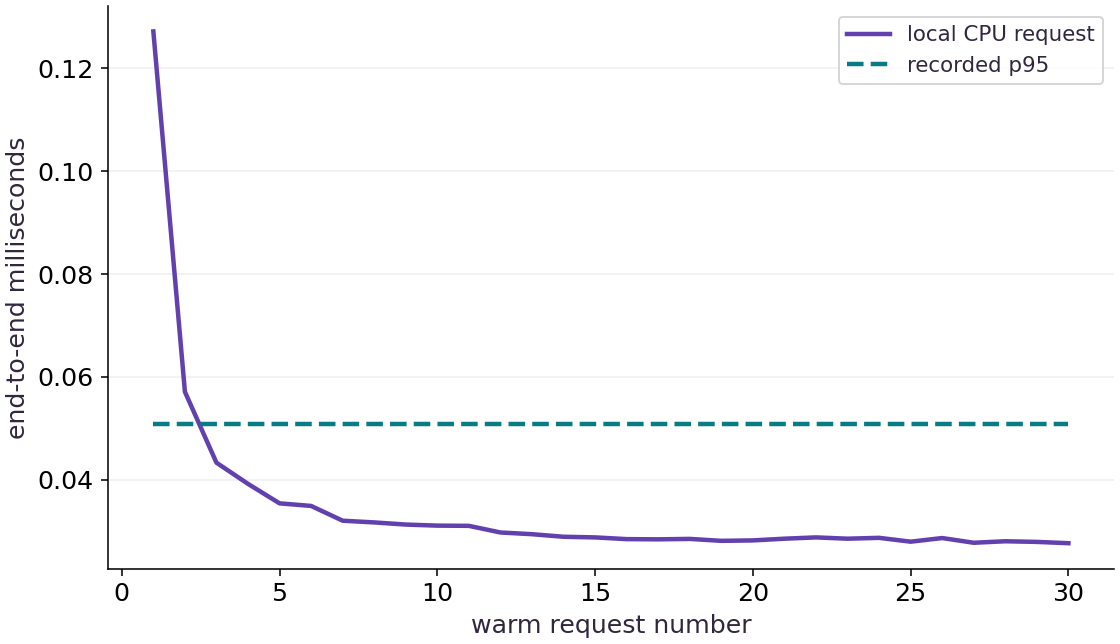

In [3]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis counts warm requests, and the vertical axis measures end-to-end latency in milliseconds. The solid line joins the measured request times. The dashed horizontal line is the empirical $95$th percentile of those same $30$ samples; it is a summary threshold, not a second implementation.

Read a solid point above the dashed line as a request slower than that percentile threshold. The line is not the maximum, so a few points can lie above it. The first cold request is reported separately and is not the first point of this warm-only plot.

### Connect it to the computation

Each duration includes JSON decoding, normalization, transfer, inference, waiting for completion, and encoding the response. That boundary explains why the chart should not be read as pure model execution time. An early high warm point or later spike shows variation in the whole request; this plot alone cannot identify its cause.

The percentile is computed from a small sample, with interpolation between ordered values. It does not guarantee that future requests will meet the threshold. Compare the sample distribution, median, and tail across repeated runs on the target device. These are local CPU proxy measurements, not evidence of mobile or edge-device latency.

## A normalization mismatch survives conversion

Predict: Will raw sensor values and normalized values produce the same scores?

In [4]:
raw = np.array([[255., 128., 0.]], np.float32)
wrong = np.asarray(infer(raw))
right = np.asarray(infer(raw / 255.))
assert not np.allclose(wrong, right)
print("Preprocessing mismatch max error", float(np.max(np.abs(wrong-right))))


Preprocessing mismatch max error 380.5019836425781


Expected: The mismatch is large despite identical weights.

Conversion checks must start at the raw input boundary when preprocessing is part of the product.

## Your exercise

Send a second raw input $[0, 255, 128]$ through the full request, and verify its independent normalized NumPy result.

In [5]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [6]:
changed_raw = np.array([[0., 255., 128.]], np.float32)
changed_response = json.loads(request(json.dumps({"features": changed_raw.tolist()})))
expected_changed = (changed_raw / 255.) @ np.asarray(weights) + np.asarray(bias)
np.testing.assert_allclose(changed_response["scores"], expected_changed, atol=1e-6)
print("Changed end-to-end request verified")

Changed end-to-end request verified


## Make incomplete deployment evidence explicit · Transfer

Create a device report template with required hardware and measurement fields. Reject it as ready while those fields are missing.

Hint: List the hardware, runtime, delegate and measurement fields before testing completeness. A missing value is different from a measured zero or an explicitly unsupported capability.

In [7]:
# Write your attempt here.

## Reference reasoning

Empty evidence stays empty. Desktop conversion and simulation cannot populate measurements for hardware that was never used.

In [8]:
device_report = {"device": None, "runtime_version": None, "delegate": None,
                 "quality_metric": None, "p95_ms": None, "peak_memory_bytes": None,
                 "cold_start_ms": None, "fallback_operators": None}
missing = [key for key, value in device_report.items() if value is None]
assert missing and "device" in missing
print("Not device-validated; missing:", ", ".join(missing))


Not device-validated; missing: device, runtime_version, delegate, quality_metric, p95_ms, peak_memory_bytes, cold_start_ms, fallback_operators


## Checkpoint

A LiteRT file converts successfully. What must happen before claiming NPU latency?

1. Run it on the named device, verify execution placement and measure the stated request boundary.
2. Divide CPU latency by the weight compression ratio.
3. Assume every operator uses the NPU.

## Diagnose

If INT8 quality drops, compare float conversion first, then verify calibration preprocessing, ranges and quantization metadata. If device latency disappoints, inspect fallback partitions, copies, request preprocessing and thermal conditions. If startup dominates, report it separately from warm inference and test the actual loading strategy.

## Evidence

Keep the CPU request report, preprocessing equivalence checks, chosen runtime/operator/precision matrix and an unfilled target-device report until actual device measurements exist. For the optional converter, retain the artifact, quantization metadata and held-out comparison.

## Primary references

- [LiteRT integer conversion tutorial](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/post_training_integer_quant)
- [LiteRT float16 conversion](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/post_training_float16_quant)
- [ONNX Runtime quantization and providers](https://onnxruntime.ai/docs/performance/model-optimizations/quantization.html)
- [ExecuTorch edge runtime](https://docs.pytorch.org/executorch/stable/index.html)
- [Core ML Tools overview](https://apple.github.io/coremltools/docs-guides/source/overview-coremltools.html)
- [LiteRT for Microcontrollers](https://developers.google.com/edge/litert/microcontrollers/overview)
- [TensorFlow installation and supported platforms](https://www.tensorflow.org/install/pip)